# Evaluation Metrics for Classification

We will use the same example as in the previous module. We basically want to answer the question "how good is it?"

## Churn prediction project

- Dataset:https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as  plt

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
!wget $data -O data-week-3.csv

--2026-10-09 11:59:15--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.004s  

2026-10-09 11:59:16 (216 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [4]:
df = pd.read_csv('data-week-3.csv')

We want to write our column names and entries consistent. We do that by writting them all in lower case and the spaces in _.

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [7]:
df.totalcharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

We obsserve that `totalcharges` is a str, lets try to convert it to a number.

In [8]:
tc = pd.to_numeric(df.totalcharges, errors = 'coerce') #conversion to numbers, we also tell python to replace arrors by missing values with null

In [9]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')

In [10]:
df.totalcharges = df.totalcharges.fillna(0)

In [11]:
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [12]:
df.churn = (df.churn == 'yes').astype(int)

In [13]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

## Setting up the validation framework
- Perform the train/validation/test split with Scikit-Learn.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)  #random_state is to ensure that the result is reproducible.

In [16]:
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)  #random_state is to ensure that the result is reproducible.

In [17]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

Next, we get our churn variables. The code below takes the column with the target variable, churn, and saves it outside the dataframe.

In [18]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

Deletes the churn columns from the dataframes to make sure we don't accidentally use the churn variable as a feature during training.

In [19]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## EDA
- Check missing values
- Look at the target variables (churn)
- Look at tthe numerical and categorical variiables

In [20]:
#For this, we shall be using our full train dataset

df_full_train = df_full_train.reset_index(drop=True)


In [21]:
#Let's look at the missing values
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [22]:
#Next, we check the distribution of values in the targett variable (churn)
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [23]:
#Now to see the proportion of the above values we do

df_full_train.churn.value_counts(normalize = True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

The churn rate in the full train dataset is $27\%$. Alternatively, we can simply calculate the mean and get the same value.

In [24]:
global_churn_rate = df_full_train.churn.mean()
print(f"The churn rate is: {round(global_churn_rate, 2)}")

The churn rate is: 0.27


Next, we create two lists from our dataset.

In [25]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [26]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [27]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [28]:
#Now, we check how many unique values each variable has. We already know that we should have just a few for each column. 
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## Feature importance: Churn rate and risk ratio
Feature importance analysis is a part of EDA that identifies which features affect our target variable.

- Churn rate
- Risk ratio
- Mutual information

### Churn rate

Before now, we saw the global churn rate. In this section, we shall check the churn rate within each group (say gender).

In [29]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [30]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
print(f"The rate of churn among females is: {round(churn_female, 3)}")

The rate of churn among females is: 0.277


In [31]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
print(f"The rate of churn among males is: {round(churn_male, 3)}")

The rate of churn among males is: 0.263


In [32]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 3)

np.float64(0.27)

The difference between the churn rate among males and females and the global churn rate is not significant and of no consequence. We can do the same analysis for the column `partner`.

In [33]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [34]:
churn_with_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
print(f"The rate of churn with partner is: {round(churn_with_partner, 3)}")

The rate of churn with partner is: 0.205


In [35]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
print(f"The rate of churn without partner is: {round(churn_no_partner, 3)}")

The rate of churn without partner is: 0.33


The difference between with or witthout partner is significant, compared to the global churn rate.

#### Risk ratio

In [36]:
churn_no_partner/global_churn_rate

np.float64(1.2216593879412643)

In [37]:
churn_with_partner/global_churn_rate

np.float64(0.7594724924338315)

In [38]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn_rate
df_group['risk'] = df_group['mean'] / global_churn_rate

df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [39]:
#This is used to display variables in a loop
from IPython.display import display

In [40]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate

    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651




phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412




multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948




internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201




onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570




onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660




deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480




techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390




streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328




streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182




contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## Feature importance: Mutual information
Mutual information - concept from information theory, it tells us how much we can learn about one variable if we know the value of another variable.

- https://en.wikipedia.org/wiki/Mutual_information

This is already implemented in Scikit-learn in the `mutual_info_score`.

In [41]:
from sklearn.metrics import mutual_info_score

In [42]:
mutual_info_score(df_full_train.churn, df_full_train.contract) #The oder in which we pass it doesn't matter

0.0983203874041556

This tells us about churn by  observing the variable contract and vice versa.

In [43]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

0.0001174846211139946

In [44]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

0.009967689095399745

Now, we apply this metric to all the categorical variables tthat we have.

In [45]:
# We define a function with only one argument because of what comes next.
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [46]:
mi = df_full_train[categorical].apply(mutual_info_churn_score) #Applies the function mutual_iinfo_churn_score to each categorical column
  
#Sorts the values in descending order.
mi.sort_values(ascending = False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## One-hot encoding
- Use Scikit-Learn to encode categorical features.

In the previous classes, we encoded it manually to get our feature matrix. However, we use scikit-learn to do it here.

In [47]:
from sklearn.feature_extraction import DictVectorizer

In [48]:
df_train[['gender', 'contract']].iloc[:100]

,gender,contract
0,female,two_year
1,male,month-to-month
2,female,month-to-month
3,female,month-to-month
4,female,two_year
...,...,...
95,male,one_year
96,female,month-to-month
97,male,month-to-month
98,male,one_year


In [49]:
dicts = df_train[['gender', 'contract']].iloc[:100].to_dict(orient= 'records') #Turns it row wise. Turns each row to a dictionary

In [50]:
dv = DictVectorizer(sparse = False) #Create a new instance for this class. We will not use the sparse here, and hence we use False.This turns the output to a numpy array

In [51]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [52]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [53]:
dv.transform(dicts) #produce a sparse matrix

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

To learn more about sparse matrix, see https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_sparse_spd_matrix.html

Dictvectorizer is smart enough to leave a column intact that is numerical(Not categorical). 

In [54]:
train_dicts = df_train[categorical + numerical].to_dict(orient= 'records')

In [55]:
train_dicts[0] #Shows the first entry of the dictionary

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [56]:
#Next, we fit our dict vectorizer

dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [57]:
dv.get_feature_names_out() #we can learn the names of all the columns

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [58]:
X_train = dv.transform(train_dicts)

In [59]:
val_dicts = df_val[categorical + numerical].to_dict(orient= 'records')

In [60]:
#We don't fit on the validatioon dataset, we just transform

X_val = dv.transform(val_dicts)

Now, we are ready to train our model.

In [61]:
from sklearn.feature_extraction import DictVectorizer


In [62]:
dv = DictVectorizer(sparse = False)

train_dicts = df_train[categorical + numerical].to_dict(orient= 'records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient= 'records')
X_val = dv.transform(val_dicts)

## Training logistic regression with Scikit-learn

- Train a model with Scikit-learn
- Apply it to the validation dataset
- Calculate the accuracy

We first import the model.

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
#we train the model by calling the fit method
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [65]:
model.intercept_ #bias term

array([-0.10913177])

In [66]:
model.intercept_[0]

np.float64(-0.10913176644533581)

In [67]:
model.coef_ #these are the weights

array([[ 4.74242775e-01, -1.74683084e-01, -4.07336941e-01,
        -2.98953565e-02, -7.78818932e-02,  6.27082428e-02,
        -8.92355821e-02, -8.12499104e-02, -3.43454752e-02,
        -7.34317745e-02, -3.34764718e-01,  3.16223051e-01,
        -8.92355821e-02,  3.67138786e-03, -2.58149284e-01,
         1.41420688e-01,  8.95134701e-03,  6.25502575e-02,
        -8.92355821e-02, -8.10919251e-02,  2.65347146e-01,
        -8.92355821e-02, -2.83888814e-01, -2.31101399e-01,
         1.23324149e-01, -1.66089070e-01,  5.83118202e-02,
        -8.69273773e-02, -3.20113694e-02,  7.03254640e-02,
        -5.91639670e-02,  1.41420688e-01, -2.49197937e-01,
         2.15252243e-01, -1.20131126e-01, -8.92355821e-02,
         1.01589458e-01, -7.07101003e-02, -8.92355821e-02,
         5.21684327e-02,  2.13164776e-01, -8.92355821e-02,
        -2.31706444e-01, -7.05146827e-02,  3.83799223e-04]])

In [68]:
model.coef_[0].round(3)

array([ 0.474, -0.175, -0.407, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.335,  0.316, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.265, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.071,  0.   ])

To use the model, we go as follows: 

In [69]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

These are Hard Predictions.

In [70]:
model.predict_proba(X_train)

array([[0.90416494, 0.09583506],
       [0.3210407 , 0.6789593 ],
       [0.36668394, 0.63331606],
       ...,
       [0.46853433, 0.53146567],
       [0.9576116 , 0.0423884 ],
       [0.30173516, 0.69826484]], shape=(4225, 2))

These are Soft Predictions. The first element of the array is the probability of belonging to $0$ and the second element is the probability of belonging to $1$.

In [71]:
y_pred = model.predict_proba(X_val)[: ,1]
y_pred

array([0.00900149, 0.20409034, 0.21172505, ..., 0.13635079, 0.79942379,
       0.83708596], shape=(1409,))

In [72]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [73]:
df_val[churn_decision].customerid #selecting all the customers that we think are going to churn

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 311, dtype: str

Now, we may decide to send them a promotional email of some discount.

Now, we see how accurate our predictions are?

In [74]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

## Accuracy and dummy model
- Evaluate the model on different thhresholds
- Check the accuracy of dummy baselines

In [75]:
len(y_val)

1409

To get the parts that we got correctly.

In [76]:
(y_val == churn_decision).sum()

np.int64(1132)

In [77]:
1132/1409

0.8034066713981547

Next, we see whether or not the threshold of $0.5$ is good.

In [78]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()

    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.667
0.20 0.710
0.25 0.737
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.765
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


In [79]:
scores

[np.float64(0.2739531582682754),
 np.float64(0.5088715400993612),
 np.float64(0.5911994322214337),
 np.float64(0.6671398154719659),
 np.float64(0.7097232079489),
 np.float64(0.7374024130589071),
 np.float64(0.7601135557132718),
 np.float64(0.7721788502484032),
 np.float64(0.7849538679914834),
 np.float64(0.7934705464868701),
 np.float64(0.8034066713981547),
 np.float64(0.801277501774308),
 np.float64(0.794889992902768),
 np.float64(0.7863733144073811),
 np.float64(0.7650816181689141),
 np.float64(0.7444996451383961),
 np.float64(0.7345635202271115),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246)]

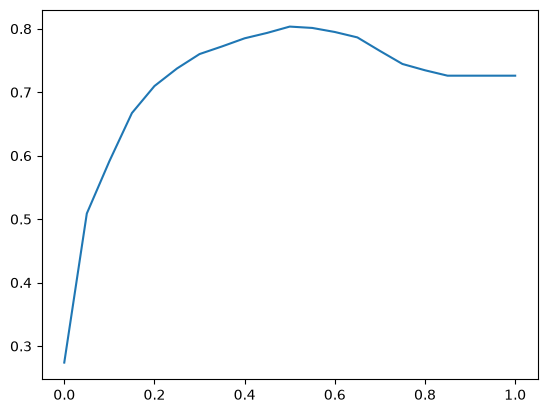

In [80]:
plt.plot(thresholds, scores)

$0.5$ is indeed the best threshold.

We can actually do all of these in scikit-learn.

In [81]:
from sklearn.metrics import accuracy_score

In [82]:
accuracy_score(y_val, (y_pred >= 0.5))

0.8034066713981547

Now, let us tak the extreme cases i.e $t = 0$ and $t = 1.0$

In [83]:
from collections import Counter # Helps us counts 

In [84]:
Counter(y_pred >= 0.5)

Counter({np.False_: 1098, np.True_: 311})

In [85]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [86]:
Counter(y_pred >= 0)

Counter({np.True_: 1409})

Let us call the model with $t = 1.0$ the dummy model, and we see that it has an accuuracy oof $73\%$ as opposed to our model ($t = 0.5$) with an accuracy of $80\%$.

In [87]:
Counter(y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

In [88]:
y_val.mean()

np.float64(0.2739531582682754)

$27\%$ of the users are churning.

## Confusion table

- Different types of errors and correct decisions
- Arranging them in a table

In [89]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [90]:
t = 0.5

predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [91]:
tp = (predict_positive & actual_positive).sum() #We use the sum() to see how many are there.
tn = (predict_negative & actual_negative).sum()

In [92]:
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [93]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]

])
confusion_matrix

array([[922, 101],
       [176, 210]])

In [94]:
#Now, we normalise it
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

## Precision and Recall

We calculate accuracy as follows:

In [95]:
(tp + tn)/(tp+fp+tn+fn)

np.float64(0.8034066713981547)

Precision tells us fractions of positive predictions that turned out to be correct

$$ Precision = \frac{tp}{tp + fp}$$

In [96]:
p = tp / (tp + fp)
p

np.float64(0.6752411575562701)

Recall is the fraction of correctly identified positive examples (i.e people who were going to churn).

$$ Recall = \frac{tp}{tp + fn} $$

In [97]:
r = tp / (tp + fn)
r

np.float64(0.5440414507772021)

## ROC Curves
ROC stands for Reciever Operating Characteristics. This is a way of describing the perforrmance of a binary classification model.

### FPR and TPR
Here, FPR is False Positive Rate, and TPR is True Positive Rrate.

In [98]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5440414507772021)

In [99]:
fpr = fp / (fp + tn)
fpr

np.float64(0.09872922776148582)

Instead of evaluating the above for just one threshold, ROC curvs looks at it for all possible thresholds. 

In [100]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum() 
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, fn, tn))

In [101]:
scores


[(np.float64(0.0), np.int64(386), np.int64(1023), np.int64(0), np.int64(0)),
 (np.float64(0.01), np.int64(385), np.int64(911), np.int64(1), np.int64(112)),
 (np.float64(0.02), np.int64(384), np.int64(829), np.int64(2), np.int64(194)),
 (np.float64(0.03), np.int64(383), np.int64(766), np.int64(3), np.int64(257)),
 (np.float64(0.04), np.int64(381), np.int64(715), np.int64(5), np.int64(308)),
 (np.float64(0.05), np.int64(379), np.int64(685), np.int64(7), np.int64(338)),
 (np.float64(0.06), np.int64(377), np.int64(660), np.int64(9), np.int64(363)),
 (np.float64(0.07), np.int64(372), np.int64(641), np.int64(14), np.int64(382)),
 (np.float64(0.08), np.int64(371), np.int64(613), np.int64(15), np.int64(410)),
 (np.float64(0.09), np.int64(369), np.int64(580), np.int64(17), np.int64(443)),
 (np.float64(0.1), np.int64(366), np.int64(556), np.int64(20), np.int64(467)),
 (np.float64(0.11), np.int64(365), np.int64(528), np.int64(21), np.int64(495)),
 (np.float64(0.12), np.int64(365), np.int64(509), 

Next, we turn it to a dataframe.

In [102]:
pd.DataFrame(scores)

,0,1,2,3,4
0,0.00,386,1023,0,0
1,0.01,385,911,1,112
2,0.02,384,829,2,194
3,0.03,383,766,3,257
4,0.04,381,715,5,308
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [103]:
columns = ['thresholds', 'tp', 'fp', 'fn', 'tn']

df_scores = pd.DataFrame(scores, columns=columns)

In [104]:
df_scores

,thresholds,tp,fp,fn,tn
0,0.00,386,1023,0,0
1,0.01,385,911,1,112
2,0.02,384,829,2,194
3,0.03,383,766,3,257
4,0.04,381,715,5,308
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [105]:
df_scores[::10]

,thresholds,tp,fp,fn,tn
0,0.0,386,1023,0,0
10,0.1,366,556,20,467
20,0.2,333,356,53,667
30,0.3,284,236,102,787
40,0.4,249,166,137,857
50,0.5,210,101,176,922
60,0.6,150,53,236,970
70,0.7,75,20,311,1003
80,0.8,13,1,373,1022
90,0.9,0,0,386,1023


In [106]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [107]:
df_scores[::10]

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,556,20,467,0.948187,0.543500
20,0.2,333,356,53,667,0.862694,0.347996
30,0.3,284,236,102,787,0.735751,0.230694
40,0.4,249,166,137,857,0.645078,0.162268
50,0.5,210,101,176,922,0.544041,0.098729
60,0.6,150,53,236,970,0.388601,0.051808
70,0.7,75,20,311,1003,0.194301,0.019550
80,0.8,13,1,373,1022,0.033679,0.000978
90,0.9,0,0,386,1023,0.000000,0.000000


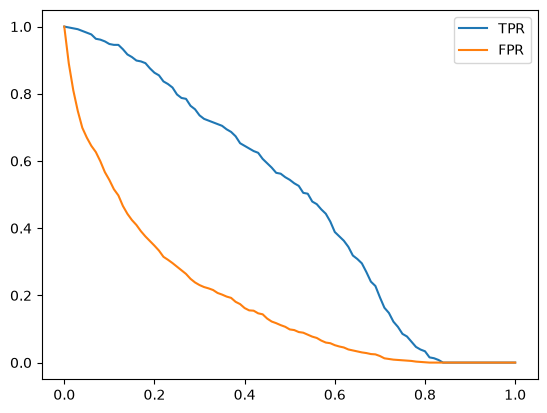

In [108]:
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR')
plt.legend() #Add the legend

## Random model

Now, we want to assign a random model to every customer.

In [109]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size = len(y_val))

In [110]:
y_rand.round(3)

array([0.417, 0.72 , 0.   , ..., 0.774, 0.334, 0.089], shape=(1409,))

In [111]:
((y_rand >= 0.5) == y_val).mean() #To check accuracy for our random model

np.float64(0.5017743080198722)

In [112]:
def tpr_fpr_dataframe(y_val, y_pred):
    
    scores = []
    
    thresholds = np.linspace(0, 1, 101)
    
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
    
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
    
        tp = (predict_positive & actual_positive).sum() 
        tn = (predict_negative & actual_negative).sum()
    
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
        scores.append((t, tp, fp, fn, tn))

    columns = ['thresholds', 'tp', 'fp', 'fn', 'tn']

    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [113]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [114]:
df_rand[::10]

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,347,923,39,100,0.898964,0.902248
20,0.2,307,822,79,201,0.795337,0.803519
30,0.3,276,724,110,299,0.715026,0.707722
40,0.4,237,624,149,399,0.613990,0.609971
50,0.5,202,518,184,505,0.523316,0.506354
60,0.6,161,409,225,614,0.417098,0.399804
70,0.7,121,302,265,721,0.313472,0.295210
80,0.8,78,206,308,817,0.202073,0.201369
90,0.9,40,101,346,922,0.103627,0.098729


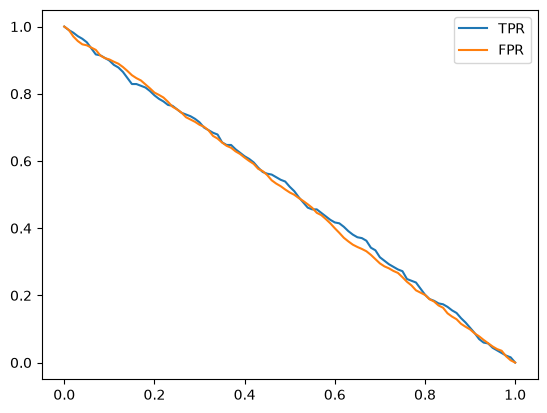

In [115]:
plt.plot(df_rand.thresholds, df_rand['tpr'], label='TPR')
plt.plot(df_rand.thresholds, df_rand['fpr'], label='FPR')
plt.legend() #Add the legend

## Ideal model

Next, we talk about a different benchmark. The ideal model (It is ideal because it gets the correct output for everyone). For that we need to first know the negative examples (i.e numbers of peope who are not churning).

In [116]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

num_neg, num_pos

(np.int64(1023), np.int64(386))

Next we want to create a list of non-churning customers, then churning ones.

In [117]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos]) #We use a function that contains first 0 then 1, using the repeat function. The number of times it repeats is given by num_neg and num_pos respectively
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

Next, we create our predictions i.e numbers between 0 and 1

In [118]:
y_ideal_pred = np.linspace(0, 1, len(y_val))

Now, tto check the accuracy, we go as follows.

In [119]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [120]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

Although this model doesn't exist in reality, it helps us to benchmark our model to this one. Now, we do an exercise for the ideal model as we did for the random model.

In [121]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)

In [122]:
df_ideal[::10]

,thresholds,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


Now, let us plot it.


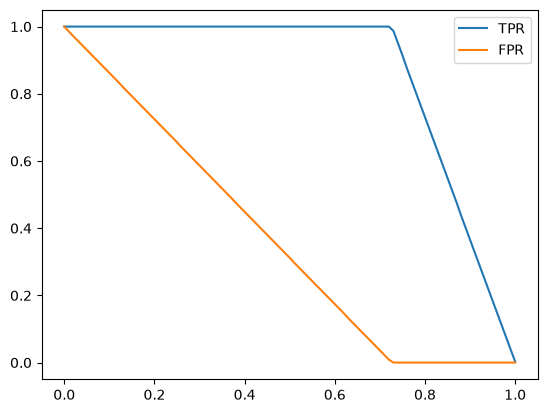

In [123]:
plt.plot(df_ideal.thresholds, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.thresholds, df_ideal['fpr'], label='FPR')
plt.legend() #Add the legend

### Putting everything together

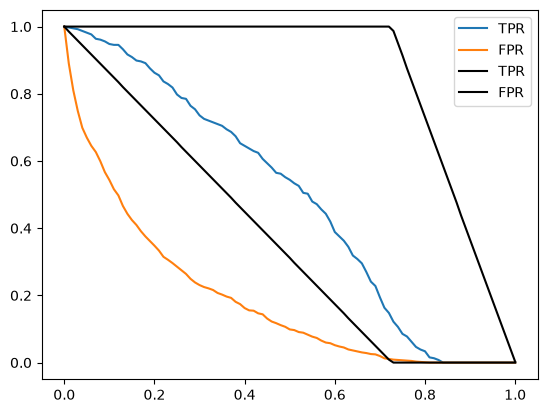

In [124]:
#Actual model
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR')

#Random model
#plt.plot(df_rand.thresholds, df_rand['tpr'], label='TPR')
#plt.plot(df_rand.thresholds, df_rand['fpr'], label='FPR')

plt.plot(df_ideal.thresholds, df_ideal['tpr'], label='TPR', color = 'black')
plt.plot(df_ideal.thresholds, df_ideal['fpr'], label='FPR', color = 'black')
plt.legend() #Add the legend

We want the TPR for the actual model to be as close to the TPR of the ideal model, from the above, we see that the blue curve is still far away from the upper black curve (Hence, we are making a mistake).

We notice that we have two thresholds $0.5$ which is good for the accuracy, and $0.726$ which is good for the ideal model. Next, we plot the FPR against the TPR.

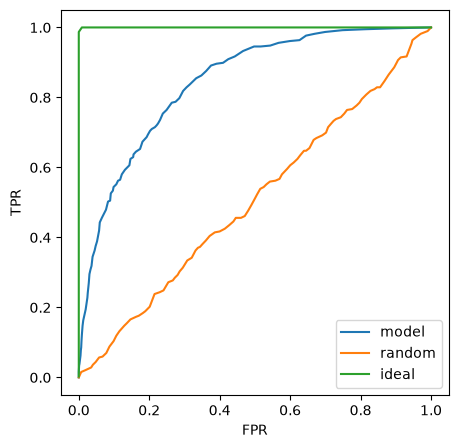

In [125]:
plt.figure(figsize=(5,5)) # To change the size of the graph

plt.plot(df_scores.fpr, df_scores.tpr, label = 'model')
plt.plot(df_rand.fpr, df_rand.tpr, label = 'random')
plt.plot(df_ideal.fpr, df_ideal.tpr, label = 'ideal')

#label the graph
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

Let us call the coordinate $(0, 1)$ the _NORTH STAR_ (ideally where we would like to get to).

Next, we plot the model, and a straight line (mimiking the random model).

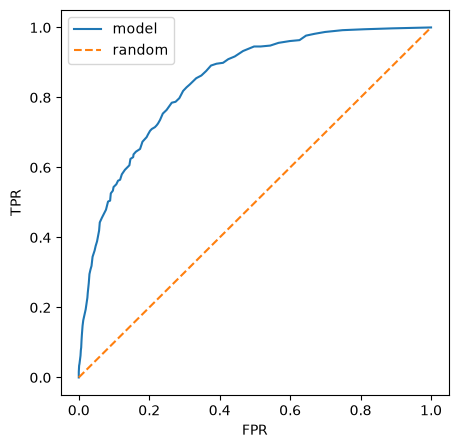

In [126]:
plt.figure(figsize=(5,5)) # To change the size of the graph

plt.plot(df_scores.fpr, df_scores.tpr, label = 'model')
plt.plot([0,1], [0,1], label = 'random', linestyle = '--')
#plt.plot(df_ideal.fpr, df_ideal.tpr, label = 'ideal')

#label the graph
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

This is how the ROC curve look like. For this, we plot the TPR against the FPR, evaluated at a particular threshold. Our aim is for the curve to be as close to the _NORTHERN STAR_ and as far away from the random baseline.

We can actually use Scikit-learn to plot the ROC curve.

In [127]:
from sklearn.metrics import roc_curve

In [128]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

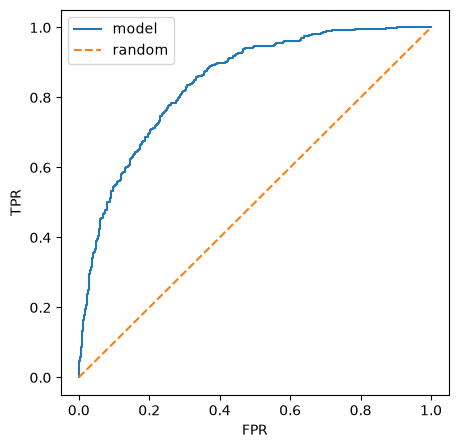

In [129]:
plt.figure(figsize=(5,5)) # To change the size of the graph

plt.plot(fpr, tpr, label = 'model')
plt.plot([0,1], [0,1], label = 'random', linestyle = '--')
#plt.plot(df_ideal.fpr, df_ideal.tpr, label = 'ideal')

#label the graph
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

Observe that the above looks like what we initially have, However, it is more accurate because it uses more thresholds that when we solved it manually.

## ROC AUC
- Area under the ROC curve
- Intrepretatioon of AUC

In [130]:
from sklearn.metrics import auc #works for any curve.

In [131]:
auc(fpr, tpr) # when we calculated it using sklearn

0.8438454408703447

In [132]:
auc(df_scores.fpr, df_scores.tpr) #when we calculated it manually

0.8437909936739956

In [133]:
auc(df_ideal.fpr, df_ideal.tpr) #when we calculated it for the ideal case

0.9999430203759136

NB: We can do this in two lines
```
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr) 

```

We can however do this in sklearn

In [134]:
from sklearn.metrics import roc_auc_score

In [135]:
roc_auc_score(y_val, y_pred)

0.8438454408703447

Basically, AUC tells us the probability that randomly selected example has a higher score than a randomly selected negative example.

In [136]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [137]:
#Next we randomly select a negative example.

import random

n = 100000
success = 0

for i in range(n):
    
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) - 1)

    if pos[pos_ind] > neg[neg_ind]:
        success = success + 1

success/n

0.84344

We can implement the above with numpy.

In [138]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size = n) #here no need for minus 1 because it is not iinclusive in numpy
neg_ind = np.random.randint(0, len(neg), size = n)

pos_ind, neg_ind

(array([ 37, 235,  72, ..., 132, 129, 277], shape=(50000,)),
 array([609, 268, 152, ..., 111,  67, 436], shape=(50000,)))

In [139]:
(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.84646)

## Cross-Validation
- Evaluating the same model on different subsets of data.
- Getting the aveerage prediction and the spread within predictions.

In [162]:
def train(df_train, y_train, C = 1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [141]:
dv, model = train(df_train, y_train, C=0.001)

In [142]:
def predict(df, dv, model):

    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)

    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [143]:
y_pred = predict(df_val, dv, model)

Now, we use K-selection. 

In [144]:
from sklearn.model_selection import KFold

In [145]:
kfold = KFold(n_splits = 10, shuffle = True, random_state = 1)



In [146]:
#train_idx, val_idx = next(kfold.split(df_full_train))

We usually don't use the next method, Ii ccomment it out above.

We import a library that tells us how long our loopp takes.

In [147]:
!pip install tqdm

In [148]:
from tqdm.auto import tqdm

In [149]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    scores = []

    kfold = KFold(n_splits = n_splits, shuffle = True, random_state = 1)


    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values
    
        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

0.001 0.825 +- 0.009


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

0.01 0.840 +- 0.008


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

0.1 0.842 +- 0.007


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

0.5 0.842 +- 0.007


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

1 0.842 +- 0.007


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

5 0.842 +- 0.007


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

10 0.842 +- 0.007


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [164]:
scores

[0.8445612327401464,
 0.8450846742153357,
 0.8333172787477423,
 0.8348048698599475,
 0.8519265162687082]

In [151]:
#np.mean(scores), np.std(scores)

In [152]:
#print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

Next, we tune our parameter.

In [153]:
#len(train_idx), len(val_idx)

In [154]:
#len(df_full_train)

In [155]:
#df_train = df_full_train.iloc[train_idx]
#df_val = df_full_train.iloc[val_idx]

Now, we go on as before, extract the dictionary, train thhe feature variiable...

In [163]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8583517501381259